# World Cup Host-Nation Effect Analysis (1930-2026)

**SQL + Python data analysis project** exploring whether hosting the FIFA World Cup
actually gives a national team an edge — using 96 years of tournament history plus
a look at the completed **2026 World Cup** (Canada / Mexico / USA), the first-ever
48-team, three-host edition.

Built on SQL and Python techniques from IBM's **"Databases and SQL for Data Science
with Python"** course (Coursera), applied to an original dataset compiled for this
project.

> **Data snapshot:** **tournament complete** as of **July 20, 2026**. Spain beat
> Argentina **1-0** in the final (Ferrán Torres, stoppage time) to win their
> second title; England beat France **6-4** in the third-place match; Kylian
> Mbappé finished as the outright top scorer with **10 goals**.

### The hook

All three 2026 host nations — Canada, Mexico, and the USA — were eliminated in the
**Round of 16**. None reached the Quarterfinals. This notebook uses SQL to check: is
that actually unusual, or does "home advantage" not mean as much as people assume?

---
### Table of Contents
**Part 1 — Host-Nation Effect (1930-2026)**
1. [Setup](#setup)
2. [All-Time Champions](#champions)
3. [Does Hosting Help? A 96-Year Look](#host-effect)
4. [2026: The Host Nations' Anomaly](#2026-hosts)
5. [2026 Round of 16 Recap](#round-of-16)
6. [Who's the Favorite? A Simple Ranking](#favorites)
7. [Part 1 Takeaways](#takeaways)

**Part 2 — Four More Questions (1994-2026)**
8. [Overview & New Datasets](#part2-intro)
9. [Q1: Does Club Form Predict the Golden Boot?](#q1)
10. [Q2: Does the Top Scorer's Team Win the Title?](#q2)
11. [Q3: CAF/AFC — Ceiling vs. Volume](#q3)
12. [Q4: Naturalized Players as a Surgical Fix](#q4)
13. [Part 2 Takeaways](#part2-takeaways)

14. [Methodology & Data Validation Log](#methodology)


## 1. Setup <a id='setup'></a>

Load the four datasets into an in-memory SQLite database using the `db_utils` module.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import db_utils

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

conn = db_utils.get_connection()
print("Tables loaded:", db_utils.list_tables(conn))


Tables loaded: ['TOURNAMENTS', 'HOST_PERFORMANCE', 'MATCHES_2026', 'TEAM_TITLES', 'TOP_SCORERS', 'TEAM_RESULTS', 'NATURALIZED_PLAYERS']


## 2. All-Time Champions <a id='champions'></a>

`West Germany` (1954, 1974, 1990) and `Germany` (2014) are the same federation under different official names — normalized with a `CASE` statement so titles are combined correctly.

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/826552518.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=champions, y="champion", x="titles", palette="mako")


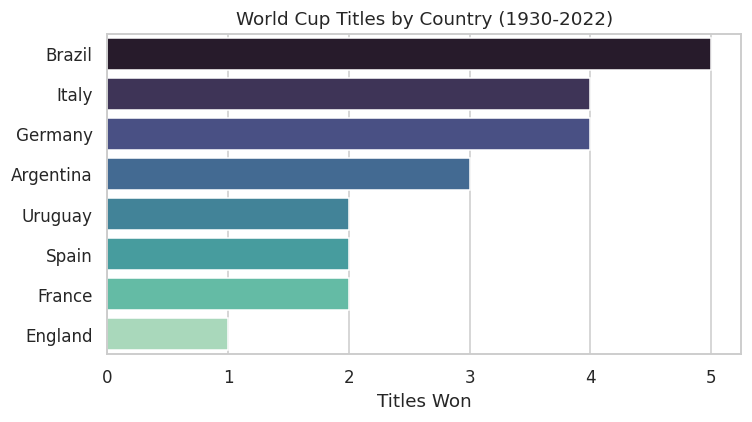

In [2]:
query = """
SELECT champion, COUNT(*) AS titles
FROM (
    SELECT CASE WHEN CHAMPION = 'West Germany' THEN 'Germany' ELSE CHAMPION END AS champion
    FROM TOURNAMENTS
    WHERE STATUS = 'Completed'
)
GROUP BY champion
ORDER BY titles DESC;
"""
champions = db_utils.run_query(conn, query)

plt.figure(figsize=(7, 4))
sns.barplot(data=champions, y="champion", x="titles", palette="mako")
plt.title("World Cup Titles by Country (1930-2022)")
plt.xlabel("Titles Won")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 3. Does Hosting Help? A 96-Year Look <a id='host-effect'></a>

What's the furthest stage host nations have historically reached?

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/2428091577.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stage_dist, y="STAGE_REACHED", x="num_hosts", order=stage_dist.sort_values("STAGE_RANK")["STAGE_REACHED"], palette="crest")


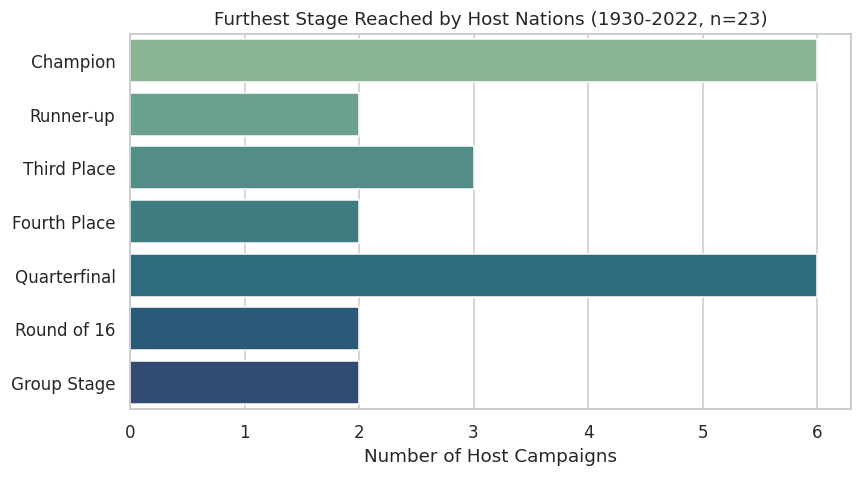

,STAGE_REACHED,STAGE_RANK,num_hosts
0,Champion,1,6
1,Runner-up,2,2
2,Third Place,3,3
3,Fourth Place,4,2
4,Quarterfinal,5,6
5,Round of 16,6,2
6,Group Stage,7,2


In [3]:
query = """
SELECT STAGE_REACHED, STAGE_RANK, COUNT(*) AS num_hosts
FROM HOST_PERFORMANCE
WHERE YEAR != 2026
GROUP BY STAGE_REACHED, STAGE_RANK
ORDER BY STAGE_RANK;
"""
stage_dist = db_utils.run_query(conn, query)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=stage_dist, y="STAGE_REACHED", x="num_hosts", order=stage_dist.sort_values("STAGE_RANK")["STAGE_REACHED"], palette="crest")
plt.title("Furthest Stage Reached by Host Nations (1930-2022, n=23)")
plt.xlabel("Number of Host Campaigns")
plt.ylabel("")
plt.tight_layout()
plt.show()

stage_dist


**Insight:** 6 of 21 tournaments (1930-2022) were won by the host nation — roughly
**29%**, a huge overperformance versus the ~4% baseline you'd expect if hosting had no
effect (with 32 teams, a random team has roughly a 1-in-32 chance of winning). Hosting
clearly correlates with success historically.

In [4]:
query = """
SELECT YEAR, HOST_COUNTRY
FROM HOST_PERFORMANCE
WHERE STAGE_RANK = 1
ORDER BY YEAR;
"""
db_utils.run_query(conn, query)


,YEAR,HOST_COUNTRY
0,1930,Uruguay
1,1934,Italy
2,1966,England
3,1974,West Germany
4,1978,Argentina
5,1998,France


### Below-average host campaigns (subquery)

Host performances worse than the historical average stage rank — the disappointments.

In [5]:
query = """
SELECT YEAR, HOST_COUNTRY, STAGE_REACHED, STAGE_RANK
FROM HOST_PERFORMANCE
WHERE STAGE_RANK > (
    SELECT AVG(STAGE_RANK) FROM HOST_PERFORMANCE WHERE YEAR != 2026
)
AND YEAR != 2026
ORDER BY STAGE_RANK DESC;
"""
db_utils.run_query(conn, query)


,YEAR,HOST_COUNTRY,STAGE_REACHED,STAGE_RANK
0,2010,South Africa,Group Stage,7
1,2022,Qatar,Group Stage,7
2,1994,USA,Round of 16,6
3,2002,Japan,Round of 16,6
4,1938,France,Quarterfinal,5
5,1954,Switzerland,Quarterfinal,5
6,1970,Mexico,Quarterfinal,5
7,1982,Spain,Quarterfinal,5
8,1986,Mexico,Quarterfinal,5
9,2018,Russia,Quarterfinal,5


## 4. 2026: The Host Nations' Anomaly <a id='2026-hosts'></a>

For the first time ever, a World Cup has **three** host nations. How did they do compared to history?

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/114877398.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=era_comparison, x="era", y="avg_stage_rank", palette="flare")


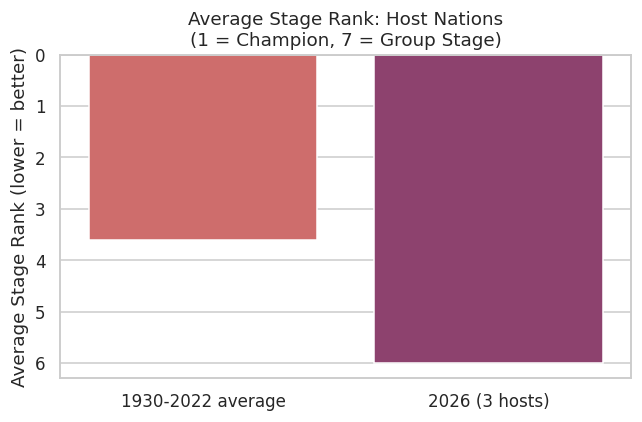

,era,avg_stage_rank,host_appearances
0,1930-2022 average,3.61,23
1,2026 (3 hosts),6.00,3


In [6]:
query = """
SELECT
    CASE WHEN YEAR = 2026 THEN '2026 (3 hosts)' ELSE '1930-2022 average' END AS era,
    ROUND(AVG(STAGE_RANK), 2) AS avg_stage_rank,
    COUNT(*) AS host_appearances
FROM HOST_PERFORMANCE
GROUP BY era;
"""
era_comparison = db_utils.run_query(conn, query)

plt.figure(figsize=(6, 4))
sns.barplot(data=era_comparison, x="era", y="avg_stage_rank", palette="flare")
plt.title("Average Stage Rank: Host Nations\n(1 = Champion, 7 = Group Stage)")
plt.ylabel("Average Stage Rank (lower = better)")
plt.xlabel("")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

era_comparison


In [7]:
query = """
SELECT YEAR, HOST_COUNTRY, STAGE_REACHED, NOTES
FROM HOST_PERFORMANCE
WHERE YEAR = 2026;
"""
db_utils.run_query(conn, query)


,YEAR,HOST_COUNTRY,STAGE_REACHED,NOTES
0,2026,Canada,Round of 16,Lost to Morocco 0-3
1,2026,USA,Round of 16,Lost to Belgium 1-4
2,2026,Mexico,Round of 16,Lost to England 2-3 at the Estadio Azteca


**Insight:** the average stage rank for 2026's three hosts (6.0, all Round of 16) is
noticeably worse than the 96-year historical host average (~3.61, closer to Quarterfinal/
Fourth Place territory). 2026 is shaping up to be one of the weakest collective host
performances on record — a real break from the historical "host advantage" pattern, even
accounting for the tougher 48-team field.

Since this is the first-ever three-host edition, there's no exact precedent to compare
against — but there is one partial precedent. 2002 (co-hosted by South Korea and Japan)
is the only other shared-hosting edition, and it already underperformed the single-host
norm: South Korea reached Fourth Place (rank 4) and Japan fell in the Round of 16 (rank 6),
averaging 5.0 versus ~3.48 for the 21 single-host editions. The progression across 1, 2, and
3 hosts (3.48 → 5.0 → 6.0) is a small sample, but it's consistent with a real mechanism:
shared hosting means each host still has to travel to the other host countries for most of
its matches, diluting the "no travel, home crowd" advantage rather than multiplying it.

## 5. 2026 Round of 16 Recap <a id='round-of-16'></a>

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/3989744197.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=r16, y="matchup", x="goal_margin", palette="rocket")


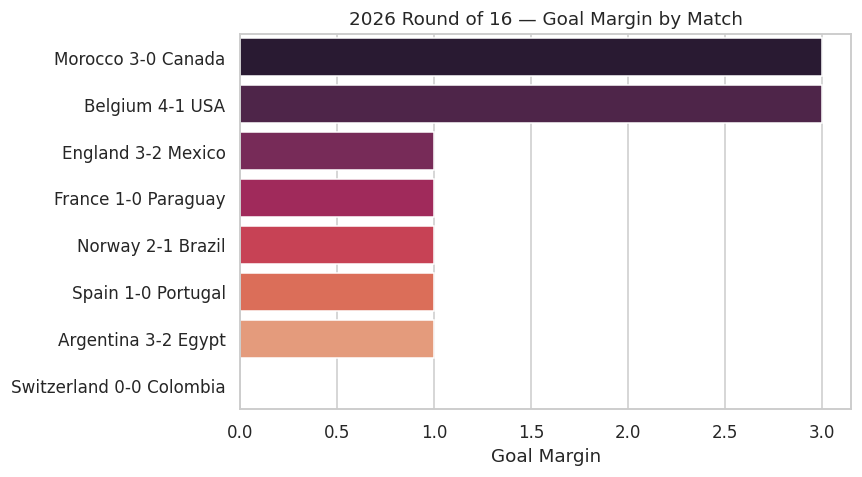

In [8]:
query = """
SELECT TEAM_1, TEAM_2, SCORE_1, SCORE_2,
       ABS(SCORE_1 - SCORE_2) AS goal_margin, DECIDED_BY
FROM MATCHES_2026
WHERE STAGE = 'Round of 16'
ORDER BY goal_margin DESC;
"""
r16 = db_utils.run_query(conn, query)

r16["matchup"] = r16["TEAM_1"] + " " + r16["SCORE_1"].astype(str) + "-" + r16["SCORE_2"].astype(str) + " " + r16["TEAM_2"]

plt.figure(figsize=(8, 4.5))
sns.barplot(data=r16, y="matchup", x="goal_margin", palette="rocket")
plt.title("2026 Round of 16 — Goal Margin by Match")
plt.xlabel("Goal Margin")
plt.ylabel("")
plt.tight_layout()
plt.show()


**Insight:** Belgium's 4-1 win over the USA and Morocco's 3-0 win over Canada were the
most one-sided Round of 16 results — two of the three host-nation eliminations were
comfortable wins for the opposition, not narrow defeats.

## 6. Who's the Favorite? A Simple Ranking <a id='favorites'></a>

Combining each Quarterfinalist's historical title count with how convincingly they won their Round of 16 match.

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/2286946666.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=favorites, y="TEAM", x="favorite_score", palette="mako")


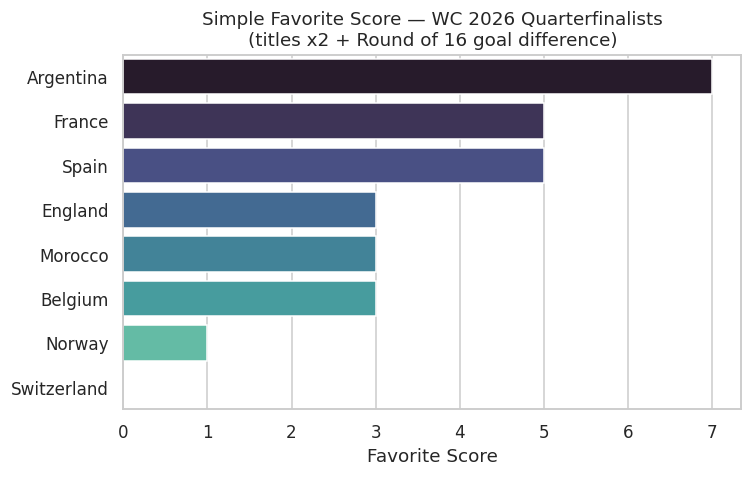

,TEAM,TITLES_WON,RUNNER_UP_FINISHES,r16_goal_diff,favorite_score
0,Argentina,3,4,1,7
1,France,2,2,1,5
2,Spain,2,0,1,5
3,England,1,0,1,3
4,Morocco,0,0,3,3
5,Belgium,0,0,3,3
6,Norway,0,0,1,1
7,Switzerland,0,0,0,0


In [9]:
query = """
SELECT
    tt.TEAM,
    tt.TITLES_WON,
    tt.RUNNER_UP_FINISHES,
    (m.SCORE_1 - m.SCORE_2) AS r16_goal_diff
FROM TEAM_TITLES tt
JOIN MATCHES_2026 m ON tt.TEAM = m.TEAM_1
WHERE m.STAGE = 'Round of 16'
ORDER BY tt.TITLES_WON DESC, r16_goal_diff DESC;
"""
favorites = db_utils.run_query(conn, query)
favorites["favorite_score"] = favorites["TITLES_WON"] * 2 + favorites["r16_goal_diff"]
favorites = favorites.sort_values("favorite_score", ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=favorites, y="TEAM", x="favorite_score", palette="mako")
plt.title("Simple Favorite Score — WC 2026 Quarterfinalists\n(titles x2 + Round of 16 goal difference)")
plt.xlabel("Favorite Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

favorites


**Insight:** this simple heuristic (pedigree + recent form) put **France** and
**Argentina** — both multiple-time champions who also won their Round of 16 matches —
at the top, ahead of the Quarterfinals. **Neither actually won the trophy.**
**Argentina** beat England to reach the final but then lost it, 1-0, to **Spain**
(Ferrán Torres, stoppage time) — a team with only one previous title, well below
the field's average pedigree. **France**, the heuristic's other top pick, never even
reached the final: eliminated by Spain in the semifinal, then beaten by England
6-4 in the third-place match. So the two most-titled teams left in the bracket
(France, Argentina) combined for a runner-up and a fourth place, while the two
one-title teams (Spain, England) took gold and bronze. The simple pedigree heuristic
was directionally useful earlier in the bracket, but it clearly did not predict the
actual outcome at the top of the tournament.

*Note: this is descriptive analysis using a transparent, simple scoring rule — not a
statistical prediction model.*

### Bonus: tournament pedigree — teams with above-average title counts

In [10]:
query = """
SELECT TEAM, TITLES_WON
FROM TEAM_TITLES
WHERE TITLES_WON > (SELECT AVG(TITLES_WON) FROM TEAM_TITLES)
ORDER BY TITLES_WON DESC;
"""
db_utils.run_query(conn, query)


,TEAM,TITLES_WON
0,Brazil,5
1,Germany,4
2,Italy,4
3,Argentina,3
4,France,2
5,Uruguay,2
6,Spain,2


### Format evolution: from 13 teams (1930) to 48 (2026)

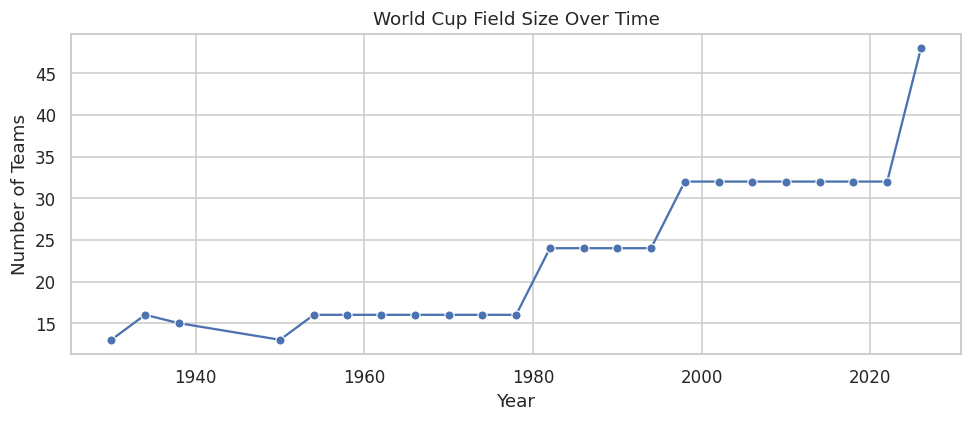

In [11]:
query = "SELECT YEAR, NUM_TEAMS FROM TOURNAMENTS ORDER BY YEAR;"
growth = db_utils.run_query(conn, query)

plt.figure(figsize=(9, 4))
sns.lineplot(data=growth, x="YEAR", y="NUM_TEAMS", marker="o")
plt.title("World Cup Field Size Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Teams")
plt.tight_layout()
plt.show()


## 7. Part 1 Takeaways <a id='takeaways'></a>

- Host nations have historically overperformed: **6 of 21** tournaments (1930-2022,
  ~29%) were won by the host — far above a random baseline.
- **2026 breaks that pattern completely.** For the first time, a World Cup has three
  host nations, and all three (Canada, Mexico, USA) were eliminated in the **Round of
  16** — none reached the Quarterfinals. Their average stage rank (6.0) is well below
  the 96-year host average (~3.61). There's no exact precedent for three hosts, but the
  one partial precedent — 2002's South Korea/Japan co-hosting (avg. rank 5.0) — already
  underperformed the single-host norm (~3.48), suggesting shared hosting dilutes home
  advantage rather than multiplying it.
- Two of the three host eliminations (Canada 0-3, USA 1-4) were comfortable wins for
  the opposition, not narrow losses.
- Using a simple pedigree + form heuristic, **France** and **Argentina** ranked as
  early favorites among the 2026 Quarterfinalists — and neither won the trophy.
  **Spain** (1 previous title) beat Argentina 1-0 in the final; **England** (1
  previous title) beat France 6-4 in the third-place match. The final result:
  **Spain champion, Argentina runner-up, England third, France fourth** — the
  pedigree heuristic pointed in a useful direction early in the bracket, but the
  two least-titled teams left standing ended up taking gold and bronze.
- The tournament has grown from 13 teams (1930) to 48 (2026), the largest single jump
  in World Cup history — a relevant context for evaluating "host advantage" going
  forward, since a bigger field means tougher knockout draws for everyone, hosts
  included.


---

## 8. Part 2: Four More Questions (1994-2026) <a id='part2-intro'></a>

Part 1 answered the question that gave this project its name — does hosting help? —
using 96 years of data. This second part asks four different, less obvious questions
about the last **nine editions (1994-2026)**, the span between the two World Cups held
in the USA.

Three new datasets, compiled via **Gemini Pro Deep Research** with schema-first prompts
and then **independently validated** against primary sources (Wikipedia's team list,
targeted web searches on the highest-risk claims) before being loaded here — see the
[Methodology & Data Validation Log](#methodology) for exactly what was checked and what
was fixed:

| Table | File | Description |
|---|---|---|
| `TOP_SCORERS` | `raw_research/top_scorers_1994_2026.csv` | Each edition's top scorer + their club-season form immediately before the tournament |
| `TEAM_RESULTS` | `raw_research/team_results_1994_2026.csv` | Every team, every edition, with confederation and furthest stage reached (296 rows) |
| `NATURALIZED_PLAYERS` | `raw_research/naturalized_players_1994_2026.csv` | 36 documented, press-covered cases of naturalized players who were key contributors |

Loaded through the same `db_utils.get_connection()` call as Part 1 — no extra setup
needed, the three tables are already available in `conn`.

## 9. Q1: Does Club Form Predict the Golden Boot? <a id='q1'></a>

Every World Cup top scorer arrives off a club season. Does a huge club-goals tally
predict who becomes the tournament's top scorer, or is Golden Boot form its own thing?

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/656355522.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scorers, x="YEAR", y="CLUB_GOALS_PRIOR_SEASON", palette="crest")


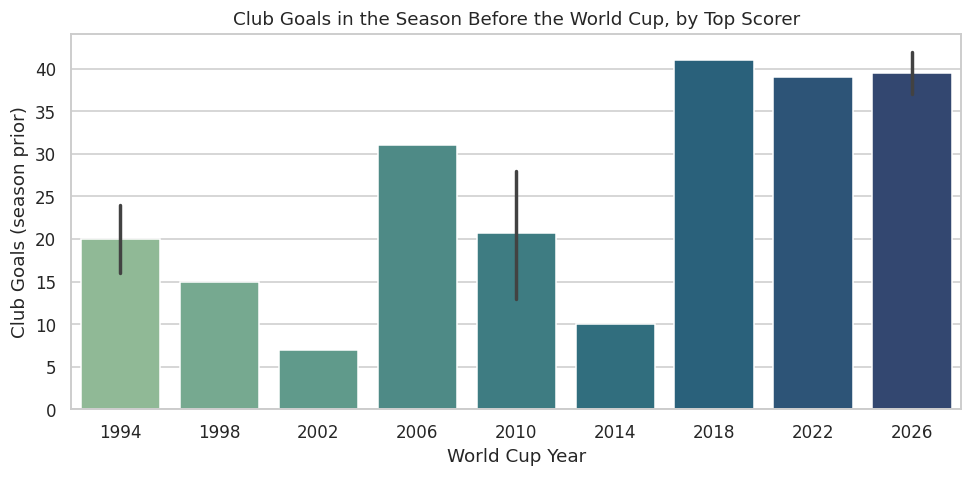

,YEAR,PLAYER_NAME,COUNTRY,WC_GOALS,CLUB_BEFORE_WC,CLUB_GOALS_PRIOR_SEASON
0,1994,Hristo Stoichkov,Bulgária,6,Barcelona,24
1,1994,Oleg Salenko,Rússia,6,CD Logroñés,16
2,1998,Davor Šuker,Croácia,6,Real Madrid,15
3,2002,Ronaldo,Brasil,8,Internazionale,7
4,2006,Miroslav Klose,Alemanha,5,Werder Bremen,31
5,2010,Thomas Müller,Alemanha,5,Bayern de Munique,19
6,2010,David Villa,Espanha,5,Valencia CF,28
7,2010,Wesley Sneijder,Holanda,5,Internazionale,8
8,2010,Diego Forlán,Uruguai,5,Atlético de Madrid,28
9,2014,James Rodríguez,Colômbia,6,AS Monaco,10


In [12]:
query = """
SELECT YEAR, PLAYER_NAME, COUNTRY, WC_GOALS, CLUB_BEFORE_WC, CLUB_GOALS_PRIOR_SEASON
FROM TOP_SCORERS
ORDER BY YEAR;
"""
scorers = db_utils.run_query(conn, query)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=scorers, x="YEAR", y="CLUB_GOALS_PRIOR_SEASON", palette="crest")
plt.title("Club Goals in the Season Before the World Cup, by Top Scorer")
plt.xlabel("World Cup Year")
plt.ylabel("Club Goals (season prior)")
plt.tight_layout()
plt.show()

scorers


**Insight:** club form ranges wildly — from **7 goals** (Ronaldo, 2002, limited by
injuries all season) to **42 goals** (Mbappé, 2025-26) — with no consistent floor.
Ronaldo's case is the sharpest counterexample: the *fewest* club goals of anyone on this
list, yet the outright Golden Boot with 8. Big club seasons (Harry Kane's 41, Mbappé's
39 and 42) do show up among the artilheiros, but so do middling ones (James Rodríguez's
10, Wesley Sneijder's 8). **Club form is not a reliable predictor of who wins the World
Cup's scoring title** — it correlates loosely with being a world-class striker in the
first place, not with peaking at the tournament itself.

## 10. Q2: Does the Top Scorer's Team Win the Title? <a id='q2'></a>

Joining `TOP_SCORERS` with `TEAM_RESULTS` on year + country answers a simple but
under-asked question: how often does the individual Golden Boot winner's team actually
lift the trophy?

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/2463821564.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="team_outcome", y="num_editions", palette="flare")


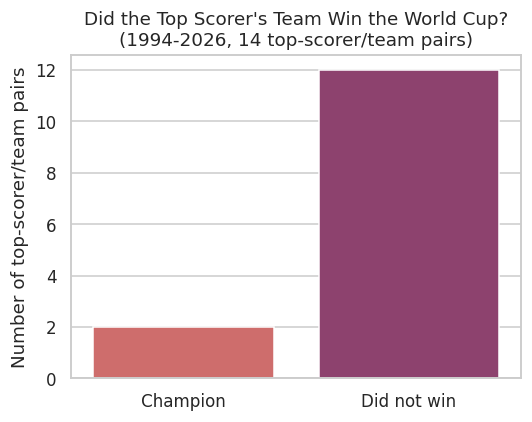

,YEAR,PLAYER_NAME,COUNTRY,WC_GOALS,STAGE_REACHED
0,1994,Hristo Stoichkov,Bulgária,6,Quarto Lugar
1,1994,Oleg Salenko,Rússia,6,Fase de Grupos
2,1998,Davor Šuker,Croácia,6,Terceiro Lugar
3,2002,Ronaldo,Brasil,8,Campeão
4,2006,Miroslav Klose,Alemanha,5,Terceiro Lugar
5,2010,Thomas Müller,Alemanha,5,Terceiro Lugar
6,2010,David Villa,Espanha,5,Campeão
7,2010,Wesley Sneijder,Holanda,5,Vice-campeão
8,2010,Diego Forlán,Uruguai,5,Quarto Lugar
9,2014,James Rodríguez,Colômbia,6,Quartos de final


In [13]:
query = """
SELECT ts.YEAR, ts.PLAYER_NAME, ts.COUNTRY, ts.WC_GOALS, tr.STAGE_REACHED
FROM TOP_SCORERS ts
JOIN TEAM_RESULTS tr ON ts.YEAR = tr.YEAR AND ts.COUNTRY = tr.TEAM
ORDER BY ts.YEAR;
"""
scorer_outcomes = db_utils.run_query(conn, query)

query_summary = """
SELECT
    CASE WHEN tr.STAGE_REACHED = 'Campeão' THEN 'Champion' ELSE 'Did not win' END AS team_outcome,
    COUNT(*) AS num_editions
FROM TOP_SCORERS ts
JOIN TEAM_RESULTS tr ON ts.YEAR = tr.YEAR AND ts.COUNTRY = tr.TEAM
GROUP BY team_outcome;
"""
summary = db_utils.run_query(conn, query_summary)

plt.figure(figsize=(5, 4))
sns.barplot(data=summary, x="team_outcome", y="num_editions", palette="flare")
plt.title("Did the Top Scorer's Team Win the World Cup?\n(1994-2026, 14 top-scorer/team pairs)")
plt.xlabel("")
plt.ylabel("Number of top-scorer/team pairs")
plt.tight_layout()
plt.show()

scorer_outcomes


**Insight:** across 14 top-scorer/team pairs since 1994 (counting every player in a
tie), the scorer's team was champion only **twice** — Ronaldo's Brazil in 2002 and
David Villa's Spain in 2010. Everyone else's team fell short, including 2026's Kylian
Mbappé: a record-setting 10 goals and an outright Golden Boot, on a France squad that
finished **fourth**. Being the tournament's best individual finisher and lifting the
trophy are, empirically, two mostly unrelated achievements — which is itself the more
interesting story than "the best scorer's team usually wins," the assumption this
question set out to test.

## 11. Q3: CAF/AFC — Ceiling vs. Volume <a id='q3'></a>

Africa (CAF) and Asia (AFC) have both received steadily more World Cup slots since
1994 — genuine volume growth. This question asks whether their *ceiling* (best result
reached in a given edition) grew at the same pace, using an ordinal stage-rank scale
(1 = Champion ... 7 = Group Stage, with 6.5 for the new 2026 "Round of 32").

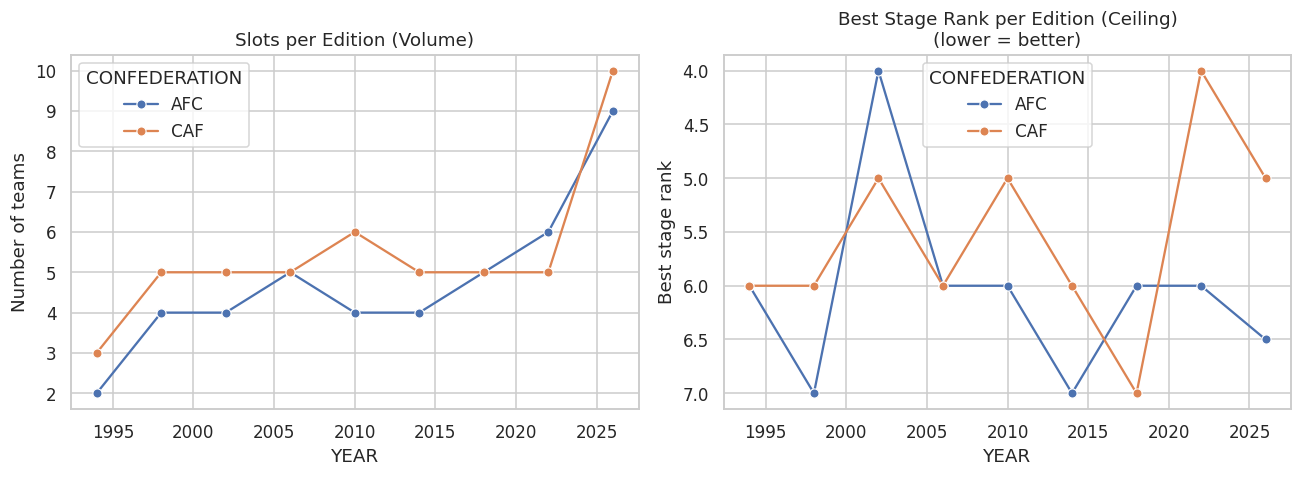

,YEAR,CONFEDERATION,NUM_VAGAS,MELHOR_RANK
0,1994,AFC,2,6.0
1,1998,AFC,4,7.0
2,2002,AFC,4,4.0
3,2006,AFC,5,6.0
4,2010,AFC,4,6.0
5,2014,AFC,4,7.0
6,2018,AFC,5,6.0
7,2022,AFC,6,6.0
8,2026,AFC,9,6.5
9,1994,CAF,3,6.0


In [14]:
RANK_CASE = """CASE STAGE_REACHED
    WHEN 'Campeão' THEN 1
    WHEN 'Vice-campeão' THEN 2
    WHEN 'Terceiro Lugar' THEN 3
    WHEN 'Quarto Lugar' THEN 4
    WHEN 'Quartos de final' THEN 5
    WHEN 'Oitavos de final' THEN 6
    WHEN '16 avos de final' THEN 6.5
    WHEN 'Fase de Grupos' THEN 7
END"""

query = f"""
SELECT slots.YEAR, slots.CONFEDERATION, slots.NUM_VAGAS, ceiling.MELHOR_RANK
FROM (
    SELECT YEAR, CONFEDERATION, COUNT(*) AS NUM_VAGAS
    FROM TEAM_RESULTS
    WHERE CONFEDERATION IN ('CAF', 'AFC')
    GROUP BY YEAR, CONFEDERATION
) slots
JOIN (
    SELECT YEAR, CONFEDERATION, MIN({RANK_CASE}) AS MELHOR_RANK
    FROM TEAM_RESULTS
    WHERE CONFEDERATION IN ('CAF', 'AFC')
    GROUP BY YEAR, CONFEDERATION
) ceiling
ON slots.YEAR = ceiling.YEAR AND slots.CONFEDERATION = ceiling.CONFEDERATION
ORDER BY slots.CONFEDERATION, slots.YEAR;
"""
ceiling_vs_volume = db_utils.run_query(conn, query)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(data=ceiling_vs_volume, x="YEAR", y="NUM_VAGAS", hue="CONFEDERATION", marker="o", ax=axes[0])
axes[0].set_title("Slots per Edition (Volume)")
axes[0].set_ylabel("Number of teams")

sns.lineplot(data=ceiling_vs_volume, x="YEAR", y="MELHOR_RANK", hue="CONFEDERATION", marker="o", ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title("Best Stage Rank per Edition (Ceiling)\n(lower = better)")
axes[1].set_ylabel("Best stage rank")

plt.tight_layout()
plt.show()

ceiling_vs_volume


**Insight:** volume growth is real and steady — AFC slots went from 2 (1994) to 9
(2026); CAF from 3 to 10. The ceiling did **not** grow in step. AFC's best-ever result
in this window is still South Korea's semifinal in **2002** (rank 4) — a year with only
4 AFC slots, fewer than most later editions. CAF's best-ever result is Morocco's
semifinal in **2022** (rank 4), with just 5 slots. In 2026, with roughly double the
slots of any prior edition, neither confederation matched that ceiling: AFC's best was
a Round of 32 exit, CAF's best a quarterfinal. **More seats at the table did not, on
this evidence, translate into a higher ceiling** — the confederations are qualifying
more teams, not (yet) more contenders.

## 12. Q4: Naturalized Players as a Surgical Fix <a id='q4'></a>

Rather than a full squad census (unreliable at scale), this question focuses on the
**36 most-documented, press-covered cases** of naturalized players (naturalized by
residency, not ancestry) who were key contributors for their adopted national team.
Does the pattern look like broad squad reinforcement, or a targeted fix for a specific
positional gap?

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/4248168721.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=positions, x="position_group", y="num_cases", palette="mako")


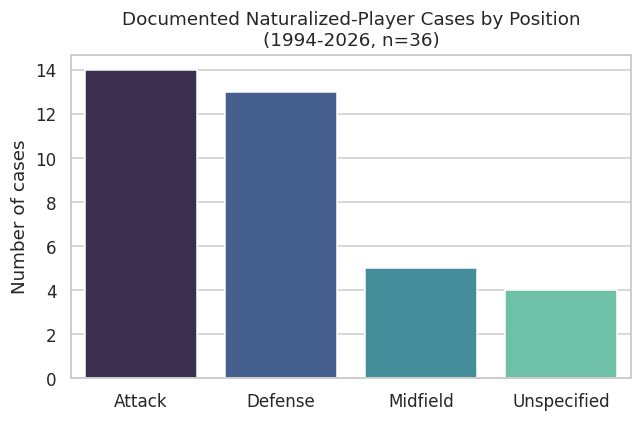

,position_group,num_cases
0,Attack,14
1,Defense,13
2,Midfield,5
3,Unspecified,4


In [15]:
query_position = """
SELECT
    CASE
        WHEN WAS_KEY_PLAYER LIKE '%agueiro%' OR WAS_KEY_PLAYER LIKE '%ateral%'
             OR WAS_KEY_PLAYER LIKE '%olante%' OR WAS_KEY_PLAYER LIKE '%efensor%'
             OR WAS_KEY_PLAYER LIKE '%a defesa%' THEN 'Defense'
        WHEN WAS_KEY_PLAYER LIKE '%tacante%' OR WAS_KEY_PLAYER LIKE '%entroavante%'
             OR WAS_KEY_PLAYER LIKE '%rtilheiro%' OR WAS_KEY_PLAYER LIKE '%ofensiv%'
             OR WAS_KEY_PLAYER LIKE '%e ataque%' THEN 'Attack'
        WHEN WAS_KEY_PLAYER LIKE '%eia %' OR WAS_KEY_PLAYER LIKE '%rmador%'
             OR WAS_KEY_PLAYER LIKE '%laymaker%' OR WAS_KEY_PLAYER LIKE '%rticulador%'
             OR WAS_KEY_PLAYER LIKE '%eio-campo%' THEN 'Midfield'
        ELSE 'Unspecified'
    END AS position_group,
    COUNT(*) AS num_cases
FROM NATURALIZED_PLAYERS
GROUP BY position_group
ORDER BY num_cases DESC;
"""
positions = db_utils.run_query(conn, query_position)

plt.figure(figsize=(6, 4))
sns.barplot(data=positions, x="position_group", y="num_cases", palette="mako")
plt.title("Documented Naturalized-Player Cases by Position\n(1994-2026, n=36)")
plt.xlabel("")
plt.ylabel("Number of cases")
plt.tight_layout()
plt.show()

positions


**Insight:** defense (13) and clear-cut finishing/attack roles (14) together account
for 27 of the 36 documented cases — the pattern looks far more like teams patching a
specific hole (a missing ball-playing centre-back, a striker who can actually score)
than a broad wave of reinforcements across the XI. Marc Guéhi's late call-up to
England's back line and Aymeric Laporte anchoring Spain's defense through their 2026
title both fit this pattern exactly: a specific structural need, filled by one player,
rather than a squad built around naturalized talent.

## 13. Part 2 Takeaways <a id='part2-takeaways'></a>

- **Club form does not predict the Golden Boot.** Ronaldo won it in 2002 with the
  *fewest* club goals of anyone in the dataset (7, injury-limited); Mbappé's
  record-setting 2026 haul came off the *most* club goals (42). No consistent floor.
- **The top scorer's team almost never wins the title.** Only 2 of 14 top-scorer/team
  pairs since 1994 ended in a championship. Mbappé's 2026 Golden Boot came with France
  finishing fourth — the sharpest recent illustration of the split.
- **CAF/AFC slot growth has not moved the ceiling.** Both confederations roughly
  doubled or tripled their slot counts since 1994, but their best-ever results (South
  Korea 2002, Morocco 2022) happened in editions with *fewer* slots than 2026, where
  neither matched that ceiling despite the largest allocation in history.
- **Naturalization reads as a targeted fix, not a trend.** 27 of 36 documented cases
  are defenders or attackers solving one specific problem for their adopted team, not
  evidence of squads being broadly rebuilt around naturalized players.

---

## 14. Methodology & Data Validation Log <a id='methodology'></a>

### Part 1 data (1930-2026)

- **Historical data (1930-2022):** compiled from well-documented, publicly available
  World Cup history (host countries, champions, runners-up, and host-nation results
  per edition), cross-checked against standard football references. Early-tournament
  team counts (pre-1950) can vary slightly by source due to withdrawals; figures here
  reflect commonly cited totals.
- **2026 data:** compiled from public news coverage. Tournament complete as of
  **July 20, 2026** — all results final, including the Spain 1-0 Argentina final and
  the England 6-4 France third-place match.
- **Stage-rank scale:** 1 = Champion, 2 = Runner-up, 3 = Third Place, 4 = Fourth Place,
  5 = Quarterfinal (or nearest historical equivalent, e.g. the 1982 second group
  round), 6 = Round of 16 (or nearest equivalent), 7 = Group Stage. Lets tournament
  formats from very different eras be compared on a consistent ordinal basis.
- **Country naming:** national teams are recorded under the name officially used at
  the time (e.g. "West Germany" through 1990); combined with "Germany" via a `CASE`
  statement where relevant for all-time totals.

### Part 2 data (1994-2026)

- **Compiled via Gemini Pro Deep Research**, using three schema-first prompts (exact
  CSV column headers specified up front, explicit source-citation and
  confidence-flagging instructions, definitional rigor for "naturalized" —
  residency/civil-process naturalization only, excluding ancestry-based eligibility
  such as Miroslav Klose's German repatriation or Morocco's diaspora players).
- **Independently validated before use, not taken at face value.** Every dataset was
  cross-checked against primary sources before being loaded into this project. Two
  concrete errors were caught and fixed this way — see the log below.
- **Naturalized-player cases are the most-documented, press-covered examples, not an
  exhaustive squad census** — deliberately scoped down from an unreliable full count
  to a smaller set of well-sourced, verifiable cases.
- **Language note:** team names, stage labels, and note fields in the Part 2 tables
  are in Portuguese (the language the Deep Research was conducted in and the
  language of most cited sources); this notebook's narrative text is in English for
  consistency with Part 1.

### Correction log

Three real errors were found and fixed during this project, each through a different
validation method — a deliberate part of the portfolio story, not an incidental detail:

1. **Stale host-average figure (Part 1).** The README and early notebook markdown
   claimed the 96-year historical host average stage rank was "~3.2." Re-running the
   actual SQL aggregate query returned **3.61**. The text had never been updated after
   an earlier data revision. Fixed across the README, this notebook, and the LinkedIn
   post — and used as an opportunity to add real supporting context (the 2002
   co-hosting precedent) instead of just correcting a number.
2. **Two non-qualified teams in the 2026 `TEAM_RESULTS` data (Part 2).** The Deep
   Research output included Cameroon and Costa Rica as 2026 participants, which would
   have made the tournament 50 teams instead of 48. A simple row-count check
   (`Counter(year)` showing 50 for 2026) flagged the discrepancy; cross-referencing
   Wikipedia's "List of team base camps" table (one row per actually-qualified team)
   confirmed both were false inclusions and both were removed.
3. **A player who never played the tournament (Part 2).** The naturalized-players
   research included Robin Le Normand as a starting centre-back for Spain's actual
   2026 World Cup squad. A targeted web search confirmed he was not selected for the
   World Cup squad at all (only for Euro 2024) — the row was removed.

### Tech Stack

`Python` · `SQLite` · `pandas` · `matplotlib` · `seaborn` · SQL (joins, subqueries,
`CASE`, aggregate functions, `GROUP BY`) · Gemini Pro Deep Research (data compilation,
independently validated)

### Course Credit

SQL techniques applied in this notebook (joins, subqueries, aggregate functions,
`GROUP BY`/`ORDER BY`, `CASE` statements) were learned in IBM's **"Databases and SQL
for Data Science with Python"** course (Coursera / IBM Data Science Professional
Certificate). All datasets, queries, and analysis are original work built for this
portfolio project.
